# Merges pMHC fold specificity and AF2 ipSAE scores for all 38 designs and produces a ranked summary table.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# Set pandas to display all columns
pd.set_option('display.max_columns', None)
# To also see all rows (optional)
pd.set_option('display.max_rows', None)

In [2]:
PMHC_PATH   = "/n/groups/marks/users/aaron/pmhc_cp/specificity/pMHC_fold/outputs/r2.5/analysis/pmhc_fold_specificity_scores.tsv"
AF2_PATH    = "/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r2.5/af2_ipae_ipsae_scores.csv"
OUT_DIR     = "/n/groups/marks/users/aaron/pmhc_cp/specificity/analysis/r2.5"
os.makedirs(OUT_DIR, exist_ok=True)

PEPTIDE_SEQ = "VVGADGVGK"  # p1-p9, D at p5
# Upward-facing positions (1-indexed in peptide): p5=D, p7=V, p9=K
# In the 8-row MPNN output (p4=A skipped), these are rows 4, 6, 8 (1-indexed within group)
# Confirmed by: V(p1) V(p2) G(p3) [A(p4) skipped] D(p5) G(p6) V(p7) G(p8) K(p9)
# So cumcount within group: 1=V(p1), 2=V(p2), 3=G(p3), 4=D(p5), 5=G(p6), 6=V(p7), 7=G(p8), 8=K(p9)
UPWARD_WT_AAS = {'D', 'V', 'K'}  # p5, p7, p9

In [3]:
# ── 1. Load AF2 ipSAE scores ──────────────────────────────────────────────────
print("Loading AF2 ipSAE scores...")
af2_df = pd.read_csv(AF2_PATH)
af2_df = af2_df.rename(columns={'label': 'design'})
af2_cols = ['design', 'ipsae_binder_peptide', 'pae_interaction', 'plddt_binder',
            'plddt_target', 'binder_aligned_rmsd', 'target_aligned_rmsd',
            'mean_pae_bp', 'n_contacts']
af2_df = af2_df[af2_cols].copy()
af2_df = af2_df[af2_df['ipsae_binder_peptide'] >= 0.8]
print(f"  {len(af2_df)} rows")

# ── 2. Load pMHC fold specificity scores ─────────────────────────────────────
print("Loading pMHC fold specificity scores...")
pmhc_df = pd.read_csv(PMHC_PATH, sep='\t')
pmhc_df = pmhc_df.rename(columns={'base_name': 'design'})
pmhc_cols = [
    'design',
    'ppi_pae_int_peptide_on', 'ppi_pae_int_peptide_off',
    'delta_pae_int_peptide',
    'plddt_peptide_on', 'plddt_peptide_off',
    'ppi_pae_int_on', 'ppi_pae_int_off',
    'delta_pae_int'
]
pmhc_df = pmhc_df[pmhc_cols].copy()
print(f"  {len(pmhc_df)} rows")

# ── 3. Merge all scores ───────────────────────────────────────────────────────
print("\nMerging all score tables...")

merged = af2_df.copy()
merged = merged.merge(pmhc_df,  on='design', how='left')

print(f"  Final merged table: {len(merged)} designs")
print(f"  Missing pMHC:  {merged['delta_pae_int_peptide'].isna().sum()}")

Loading AF2 ipSAE scores...
  38 rows
Loading pMHC fold specificity scores...
  38 rows

Merging all score tables...
  Final merged table: 38 designs
  Missing pMHC:  0


In [4]:
# ── 4. Compute per-metric ranks ───────────────────────────────────────────────
# For each metric, rank such that rank 1 = best design

# ipSAE: higher = better
merged['rank_ipsae'] = merged['ipsae_binder_peptide'].rank(ascending=False)

# pMHC fold Δ pAE_int_peptide: more negative = better
merged['rank_pmhc_spec'] = merged['delta_pae_int_peptide'].rank(ascending=True)

# pMHC fold on-target pAE_int_peptide: lower = better
merged['rank_pmhc_on'] = merged['ppi_pae_int_peptide_on'].rank(ascending=True)

# # ── 5. Combined rank ──────────────────────────────────────────────────────────
# # Primary filters already applied (ipSAE >= 0.8) — all 199 pass
# # Combine ranks with equal weighting across the three specificity metrics:
# #   pMHC fold Δ pAE, CMS p5, MPNN Δ p5
# # Plus ipSAE as a quality anchor
# merged['rank_combined'] = (
#     merged['rank_ipsae'] +
#     merged['rank_cms_p5'] +
#     merged['rank_pmhc_spec'] +
#     merged['rank_mpnn_p5']
# ) / 4

# merged = merged.sort_values('rank_combined')

# ── 6. Save ───────────────────────────────────────────────────────────────────
out_path = os.path.join(OUT_DIR, 'merged_scores_ranked.tsv')
merged.to_csv(out_path, sep='\t', index=False)
print(f"\nSaved merged ranked table to {out_path}")

# ── 7. Summary table (top 30) ─────────────────────────────────────────────────
summary_cols = [
    'design',
    'ipsae_binder_peptide',
    'pae_interaction',
    'plddt_binder',
    'delta_pae_int_peptide',
    'ppi_pae_int_peptide_on',
    'ppi_pae_int_peptide_off',
    'rank_ipsae',
    'rank_pmhc_spec',
#     'rank_combined',
]


Saved merged ranked table to /n/groups/marks/users/aaron/pmhc_cp/specificity/analysis/r2.5/merged_scores_ranked.tsv


In [5]:
# ── 8. Correlation between metrics ──────────────────────────────────────────
print("\n── Spearman correlations between specificity metrics ──")
spec_cols = [
    'ipsae_binder_peptide',
    'delta_pae_int_peptide',
    'ppi_pae_int_peptide_on',
]
# Friendlier axis labels
labels = [
    'ipSAE\n(binder-peptide)',
    'Δ pAE_int_peptide\n(pMHC fold spec.)',
    'pAE_int_peptide\n(on-target)',
]
corr = merged[spec_cols].corr(method='spearman').round(3)
print(corr.to_string())

corr_path = os.path.join(OUT_DIR, 'metric_correlations.tsv')
corr.to_csv(corr_path, sep='\t')
print(f"Correlation matrix saved to {corr_path}")

print("\nDone.")


── Spearman correlations between specificity metrics ──
                        ipsae_binder_peptide  delta_pae_int_peptide  ppi_pae_int_peptide_on
ipsae_binder_peptide                   1.000                 -0.017                  -0.533
delta_pae_int_peptide                 -0.017                  1.000                   0.207
ppi_pae_int_peptide_on                -0.533                  0.207                   1.000
Correlation matrix saved to /n/groups/marks/users/aaron/pmhc_cp/specificity/analysis/r2.5/metric_correlations.tsv

Done.


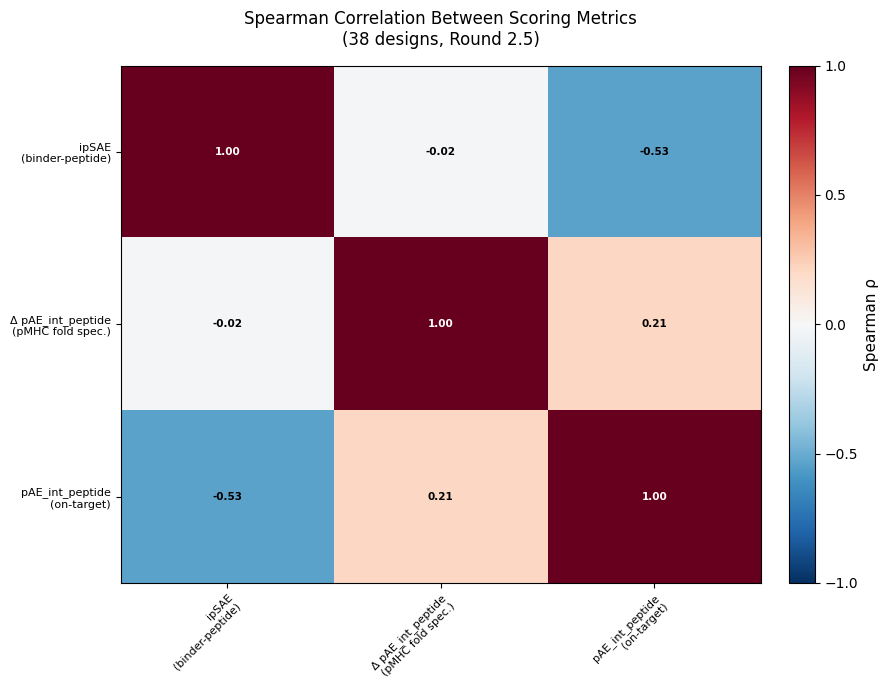

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman ρ", fontsize=11)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

# Tick labels
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right', rotation_mode='anchor')
ax.set_yticklabels(labels, fontsize=8)

# Annotate cells with correlation values
for i in range(len(spec_cols)):
    for j in range(len(spec_cols)):
        val = corr.values[i, j]
        # Use white text on dark cells, black on light cells
        text_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=text_color, fontweight='bold')

ax.set_title('Spearman Correlation Between Scoring Metrics\n(38 designs, Round 2.5)',
             fontsize=12, pad=15)

plt.tight_layout()
plt.show()
# fig.savefig(f"{OUT_DIR}/metric_correlation_heatmap.png", dpi=150, bbox_inches='tight')
# print(f"Saved to {OUT_DIR}/metric_correlation_heatmap.png")
# plt.close()

In [15]:
print(len(merged[merged['delta_pae_int_peptide']<-0.5]))
merged[merged['delta_pae_int_peptide']<-0.5].sort_values('delta_pae_int_peptide', ascending=True)

49


,design,ipsae_binder_peptide,pae_interaction,plddt_binder,plddt_target,binder_aligned_rmsd,target_aligned_rmsd,mean_pae_bp,n_contacts,cms_p5_neoepitope,cms_peptide_total,ppi_pae_int_peptide_on,ppi_pae_int_peptide_off,delta_pae_int_peptide,plddt_peptide_on,plddt_peptide_off,ppi_pae_int_on,ppi_pae_int_off,delta_pae_int,mpnn_delta_p5_DA,mpnn_delta_upward_mean,mpnn_delta_all_mean,rank_ipsae,rank_cms_p5,rank_cms_total,rank_pmhc_spec,rank_pmhc_on,rank_mpnn_p5,rank_mpnn_upward
65,orient_255_pT12__33_sample06_af2pred,0.8359,5.132,92.569,95.460,0.410,0.995,4.339,830,49.9967,157.7712,12.639,16.621,-3.982,59.896,72.601,6.194,15.091,-8.897,1.875768,-0.516765,-0.115169,124.5,8.0,31.0,1.0,1.0,20.0,18.0
1,orient_158_pT12__76_sample04_af2pred,0.8491,4.272,93.365,95.841,0.412,2.102,3.325,522,41.7730,135.8636,13.553,16.957,-3.404,52.258,70.586,7.319,16.089,-8.770,3.311519,0.340083,0.349214,95.5,30.0,84.0,2.0,2.0,114.0,144.0
30,orient_255_pT12__0_sample02_af2pred,0.8611,4.897,93.357,95.654,0.446,0.911,4.053,819,39.7403,138.9544,16.906,19.796,-2.890,45.593,68.533,10.206,18.930,-8.724,2.990534,-0.042800,-0.060366,74.0,49.0,74.0,3.0,120.0,88.0,86.0
2,orient_158_pT12__76_sample07_af2pred,0.8159,4.864,90.356,95.464,0.388,0.831,3.955,514,42.6509,154.6356,13.662,16.361,-2.699,50.507,71.030,7.021,15.266,-8.245,2.676896,0.086225,0.429201,177.0,23.0,39.0,4.0,3.0,71.0,112.0
40,orient_255_pT12__18_sample01_af2pred,0.8689,4.789,93.818,95.625,1.079,2.055,3.922,820,37.9600,141.6554,16.634,19.035,-2.401,47.322,72.163,9.935,18.339,-8.404,3.944891,0.192738,0.167779,54.0,73.0,68.0,5.0,74.0,161.0,127.0
99,orient_255_pT12__81_sample05_af2pred,0.8022,6.060,93.209,94.838,0.603,2.169,4.876,830,38.1511,159.4019,16.676,18.956,-2.280,46.156,69.559,9.774,17.691,-7.917,2.263180,-0.506489,-0.113751,198.0,71.0,28.0,6.0,82.0,37.0,21.0
0,orient_158_pT12__64_sample01_af2pred,0.8354,4.599,92.792,95.518,0.540,0.949,3.641,516,44.6481,163.3551,14.951,17.181,-2.230,46.815,69.515,9.988,16.431,-6.443,3.026507,-0.027636,0.017046,129.0,19.0,21.0,7.0,8.0,91.0,89.0
71,orient_255_pT12__46_sample01_af2pred,0.8618,5.083,93.659,95.510,0.494,1.559,4.035,818,37.0386,135.0677,16.575,18.683,-2.108,44.974,67.132,9.504,17.468,-7.964,3.157815,-0.133147,-0.026188,68.5,91.0,89.0,8.0,67.0,103.0,74.0
63,orient_255_pT12__33_sample04_af2pred,0.8590,4.737,91.666,95.786,0.660,1.566,3.989,825,53.8498,168.7588,16.006,17.949,-1.943,47.902,68.693,9.531,16.741,-7.210,1.761580,-0.646739,-0.167826,78.5,3.0,15.0,9.0,22.0,13.0,11.0
47,orient_255_pT12__27_sample02_af2pred,0.8385,4.953,93.390,95.158,0.390,1.570,4.321,828,33.1573,112.7215,16.140,17.972,-1.832,48.423,71.486,9.665,16.654,-6.989,3.285811,0.673096,0.339609,120.0,140.0,166.0,10.0,25.0,113.0,162.0
